<a href="https://colab.research.google.com/github/deriiinjv/pytorch-ml-experiments/blob/main/LoG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

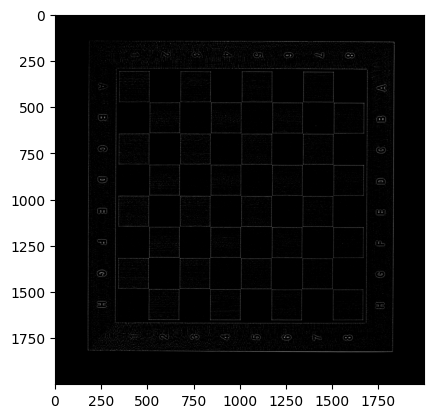

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
def LoG_filter_opencv(image, sigma, size=None):

    if size is None:
        size = int(6 * sigma + 1) if sigma >= 1 else 7

    if size % 2 == 0:
        size += 1

    x, y = np.meshgrid(np.arange(-size//2+1, size//2+1), np.arange(-size//2+1, size//2+1))
    kernel = -(1/(np.pi * sigma**4)) * (1 - ((x**2 + y**2) / (2 * sigma**2))) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(np.abs(kernel))


    result = cv2.filter2D(image, -1, kernel)

    return result

image = cv2.imread(r"/content/81vMuVeEY0L.jpg", cv2.IMREAD_GRAYSCALE)  # Replace 'path_to_your_image.png' with your image path
sigma = 2.0
filtered_image = LoG_filter_opencv(image, sigma)
filtered_image = cv2.convertScaleAbs(filtered_image)
plt.imshow(filtered_image, cmap="gray")